# Florentine families

In [1]:
import sys
import os
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import jax
import jax.numpy as jnp

## Network

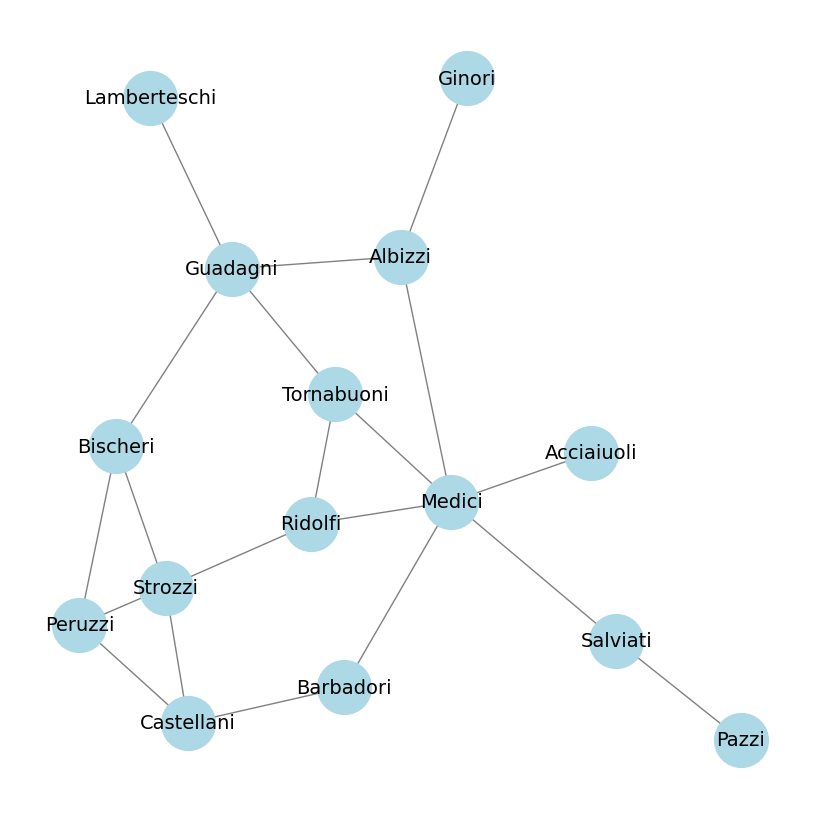

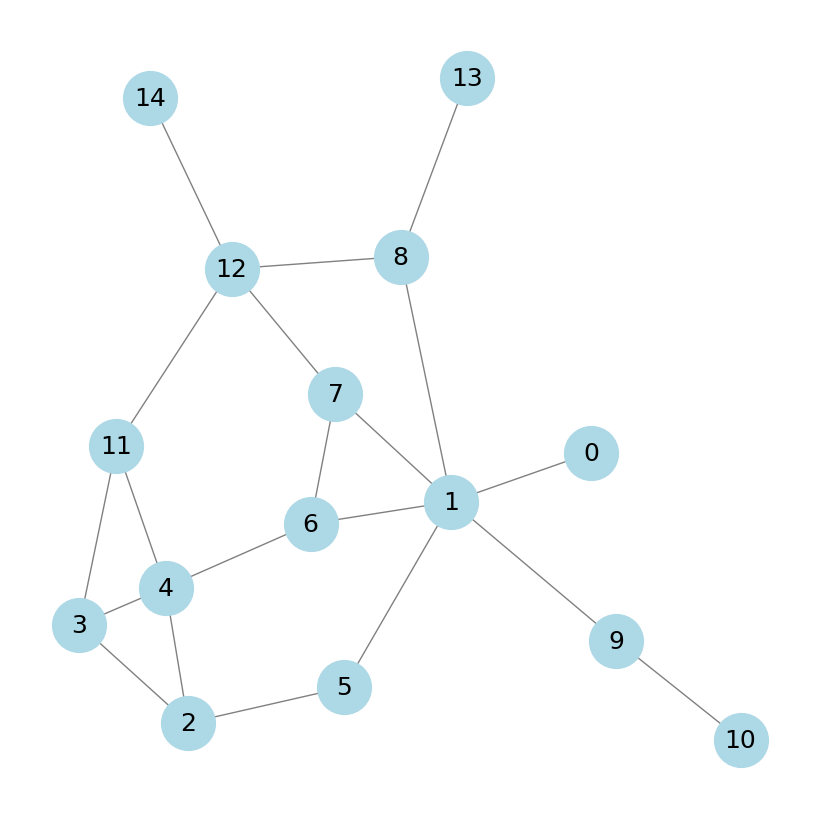

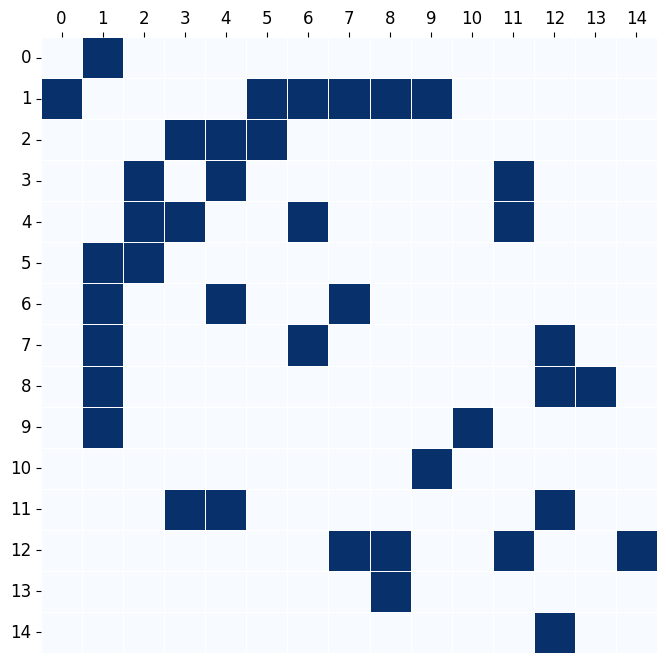

In [2]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
plt.figure(figsize=(8,8))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)
plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

## Code

### Geometry

Base

In [3]:
class Geometry:
    def distance(self, zi, zj):
        raise NotImplementedError
    def distance_matrix(self, Z):
        raise NotImplementedError
    def project_to_tangent(self, z, v):
        raise NotImplementedError
    def project_to_domain(self, z):
        raise NotImplementedError
    def logaritmic_map(self, z, zp):
        raise NotImplementedError
    def exponential_map(self, z, v):
        raise NotImplementedError
    def identifiability_transform(self, Z, Z_ref):
        raise NotImplementedError
    def sample_uniform_Z(self, n:int, seed:int):
        raise NotImplementedError

Simplex

In [4]:
class Simplex:
    def __init__(self, n):
        self.n = n
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.exponential_map   = jax.jit(self._exponential_map)

    # Tangent projection
    def _project_to_tangent(self, xi, v):
        mean_v = jnp.mean(v)
        return v - mean_v

    # Projection to simplex
    def _project_to_domain(self, xi):
        xi = jnp.maximum(xi, 1e-12)
        return self.n * xi / jnp.sum(xi)

    # Exponential map 
    def _exponential_map(self, xi, v):
        xi_new = xi * jnp.exp(v)
        return self.n * xi_new / jnp.sum(xi_new)

Euclidean

In [5]:
class EuclideanGeometry(Geometry):
    def __init__(self, d, D=None):
        self.d = d
        self.D = D  
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))

    # distance 
    def _distance(self, zi, zj):
        diff = zi - zj
        return jnp.sqrt(jnp.sum(diff**2) + 1e-12)
    
    # distance matrix
    def _distance_matrix(self, Z):
        diff = Z[:, None, :] - Z[None, :, :]
        return jnp.sqrt(jnp.sum(diff**2, axis=-1) + 1e-12)
    
    # tangent projection 
    def _project_to_tangent(self, z, v):
        return v
    
    # domain projection
    def _project_to_domain(self, z):
        if self.D is None:
            return z
        radius = self.D / 2.0
        norm = jnp.linalg.norm(z)
        factor = jnp.minimum(1.0, radius / (norm + 1e-12))
        return z * factor
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        v = zp - z
        return v
    
    # exponential map 
    def _exponential_map(self, z, v):
        y = z + v
        return y 
    
    # identifiability 
    def _identifiability_transform(self, Z, Z_ref):
        Zc = Z - jnp.mean(Z, axis=0, keepdims=True)
        Z0c = Z_ref - jnp.mean(Z_ref, axis=0, keepdims=True)
        A = Zc @ Z0c.T @ Z0c @ Zc.T
        U, S, Vt = jnp.linalg.svd(A)
        S_inv_sqrt = 1.0 / (jnp.sqrt(S) + 1e-10)
        A_inv_sqrt = U @ jnp.diag(S_inv_sqrt) @ U.T
        Z_star = Z0c @ Zc.T @ A_inv_sqrt @ Zc
        Z_star = Z_star - jnp.mean(Z_star, axis=0, keepdims=True)
        return Z_star
    
    # sampling
    def sample_uniform_Z(self, n: int, key):
        if self.D is None:
            Z = jax.random.normal(key, shape=(n, self.d))
            return Z
        R = self.D / 2.0
        key1, key2 = jax.random.split(key)
        X = jax.random.normal(key1, shape=(n, self.d))
        norms = jnp.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        directions = X / norms
        u = jax.random.uniform(key2, shape=(n, 1))
        radii = R * (u ** (1.0 / self.d))
        Z = directions * radii
        return Z

Spherical

In [6]:
class SphericalGeometry(Geometry):
    def __init__(self, d, R=1.0, D = jnp.pi):
        self.d = d
        self.R = R
        self.D = D
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))
    
    # distance on S^d(R) 
    def _distance(self, zi, zj):
        dot = jnp.dot(zi, zj) / (self.R**2)
        dot = jnp.clip(dot, -1.0 + 1e-7, 1.0 - 1e-7)
        return self.R * jnp.arccos(dot)
    
    # distance matrix 
    def _distance_matrix(self, Z):
        dot = (Z @ Z.T) / (self.R**2)
        dot = jnp.clip(dot, -1.0 + 1e-7, 1.0 - 1e-7)
        return self.R * jnp.arccos(dot)
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        dot = jnp.clip(jnp.dot(z, zp) / (self.R**2), -1.0 + 1e-12, 1.0 - 1e-12)
        theta = jnp.arccos(dot)
        sin_theta = jnp.sin(theta)
        factor = theta / (sin_theta + 1e-12)
        v = factor * (zp - dot * z)
        return v
    
    # projection to tangent space 
    def _project_to_tangent(self, z, v):
        return v - (jnp.dot(z, v) / (self.R**2)) * z
    
    # domain projection
    def _project_to_domain(self, z):
        norm = jnp.linalg.norm(z) + 1e-12
        return self.R * z / norm
  
    
    # exponential map 
    def _exponential_map(self, z, v):
        norm_v = jnp.linalg.norm(v)
        eps = 1e-12
        coef1 = jnp.cos(norm_v / self.R)
        coef2 = jnp.sin(norm_v / self.R) / (norm_v + eps)
        y = coef1 * z + coef2 * v
        return y
    
    # identifiability 
    def _identifiability_transform(self, Z , Z_ref):
        return Z

Hyperbolic

In [7]:
class HyperbolicGeometry(Geometry):
    def __init__(self, d, R=1.0, D=None):
        self.d = d
        self.R = R
        self.D = D
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))

    # Lorentz inner product 
    def _lorentz_inner(self, zi, zj):
        return jnp.dot(zi[:-1], zj[:-1]) - zi[-1] * zj[-1]
    
    # distance
    def _distance(self, zi, zj):
        inner = self._lorentz_inner(zi, zj)
        x = -inner / (self.R**2)
        x = jnp.clip(x, 1.0 + 1e-7, None)
        return self.R * jnp.arccosh(x)
    
    # distance matrix
    def _distance_matrix(self, Z):
        spatial = Z[:, :-1]
        time = Z[:, -1]
        inner = spatial @ spatial.T - jnp.outer(time, time)
        x = -inner / (self.R**2)
        x = jnp.maximum(x, 1.0 + 1e-7)
        return self.R * jnp.arccosh(x)
    
    # projection to tangent 
    def _project_to_tangent(self, z, v):
        # T_z H^d = {v : <z,v>_L = 0}
        inner = self._lorentz_inner(z, v)
        return v + (inner / (self.R**2)) * z
    
    # domain projection
    def _project_to_domain(self, z):
        t_max = self.R * jnp.cosh(self.D / (2 * self.R))
        x = z[:-1]
        t = z[-1]
        def inside():
            return z
        def outside():
            norm_x = jnp.linalg.norm(x) + 1e-12
            new_norm = jnp.sqrt(t_max**2 - self.R**2)
            factor = new_norm / norm_x
            x_new = x * factor
            return jnp.concatenate([x_new, jnp.array([t_max])])
        return jax.lax.cond(t <= t_max, inside, outside)
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        dot = self._lorentz_inner(z, zp)
        alpha = -dot  # debe ser ≥ 1
        omega = jnp.arccosh(alpha)
        denom = jnp.sqrt(alpha**2 - 1.0 + 1e-12)
        v = (omega / (denom + 1e-12)) * (zp + (dot / (self.R**2)) * z)
        return self._project_to_tangent(z, v)
    
    # exponential map 
    def _exponential_map(self, z, v):
        norm_v_sq = self._lorentz_inner(v, v)
        norm_v = jnp.sqrt(jnp.maximum(norm_v_sq, 1e-12))
        coef1 = jnp.cosh(norm_v / self.R)
        coef2 = jnp.sinh(norm_v / self.R) / (norm_v + 1e-12)
        z_new = coef1 * z + coef2 * v
        return z_new
    
    # identifiability 
    def _identifiability_transform(self, Z, Z_ref):
        return Z

### Likelihood

In [8]:
class LatentSpaceLikelihood:
    def __init__(self, geometry):
        self.geometry = geometry
        self.loglikelihood = jax.jit(self._loglikelihood)
        self.grad_alpha0 = jax.jit(jax.grad(self._loglikelihood, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._loglikelihood, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._loglikelihood, argnums=2))
    # predictor
    def _predictor(self, alpha0, xi, Z):
        D = self.geometry.distance_matrix(Z)
        xi_i = xi[:, None]
        xi_j = xi[None, :]
        S = alpha0 - 0.5 * (xi_i + xi_j) * D
        return S
    # loglikelihood
    def _loglikelihood(self, alpha0, xi, Z, Y):
        S = self._predictor(alpha0, xi, Z)
        mask = jnp.triu(jnp.ones_like(Y), k=1)
        loglik = Y * S - jax.nn.softplus(S)
        return jnp.sum(loglik * mask)
    # gradients
    def gradients(self, alpha0, xi, Z, Y):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z, Y), "xi": self.grad_xi(alpha0, xi, Z, Y), "Z": self.grad_Z(alpha0, xi, Z, Y)}

### Prior

In [9]:
class LatentSpacePrior:
    def __init__(self, geometry, sigma2_alpha0=10.0, a_xi=2.0, fixed_params:dict = {}):
        self.sigma2_alpha0 = sigma2_alpha0
        self.a_xi = a_xi
        self.geometry = geometry
        self.fixed_params = fixed_params
        self.fix_alpha0 = "alpha0" in fixed_params
        if self.fix_alpha0:
            self.alpha0_fixed = self.fixed_params.get("alpha0", None)
        self.fix_xi     = "xi" in fixed_params
        if self.fix_xi:
            self.xi_fixed = self.fixed_params.get("xi", None)
        self.fix_Z      = "Z" in fixed_params
        if self.fix_Z:
            self.Z_fixed = self.fixed_params.get("Z", None)
         
        self.log_prior_density = jax.jit(self._log_prior_density)
        self.grad_alpha0 = jax.jit(jax.grad(self._log_prior_density, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._log_prior_density, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._log_prior_density, argnums=2))
        

    #  log prior 
    def _log_prior_density(self, alpha0, xi, Z):
        logp = 0.0
        # alpha0 ~ N(0, sigma2)
        if not self.fix_alpha0:
            logp += -0.5 * (jnp.log(self.sigma2_alpha0) + alpha0**2 / self.sigma2_alpha0)
        # xi ~ Dirichlet 
        if not self.fix_xi:
            xi_safe = jnp.clip(xi, 1e-12, 1e6)
            logp += jnp.sum((self.a_xi - 1.0) * jnp.log(xi_safe))
        # Z ~ Uniform
        if not self.fix_Z:
            logp += 0.0
        return logp

    # gradients
    def gradients(self, alpha0, xi, Z):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z),"xi": self.grad_xi(alpha0, xi, Z),"Z": self.grad_Z(alpha0, xi, Z)}

    # sampling
    def sample(self, n, seed=42):
        key = jax.random.PRNGKey(seed)
        keys = jax.random.split(key, 3)
        # alpha0
        if self.fix_alpha0:
            alpha0 = self.alpha0_fixed
        else:
            alpha0 = jnp.sqrt(self.sigma2_alpha0) * jax.random.normal(keys[0])
        # xi
        if self.fix_xi:
            xi = self.xi_fixed
            assert xi.shape[0] == n, "xi hasn't correct dimension"
        else:
            a_vec = jnp.ones(n) * self.a_xi
            xi = jax.random.dirichlet(keys[1], a_vec)
            xi = n * xi
        # Z
        if self.fix_Z:
            Z = self.Z_fixed
            assert Z.shape == (n, self.geometry.d), "Z hasn't correct dimension"
        else:
            Z = self.geometry.sample_uniform_Z(n, keys[2])
        return alpha0, xi, Z

### Posterior

In [10]:
class LatentSpacePosterior:
    def __init__(self, likelihood, prior):
        self.likelihood = likelihood
        self.prior = prior
        self.log_posterior = jax.jit(self._log_posterior)
        self.grad_alpha0 = jax.jit(jax.grad(self._log_posterior, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._log_posterior, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._log_posterior, argnums=2))
    # log posterior 
    def _log_posterior(self, alpha0, xi, Z, Y):
        loglik = self.likelihood.loglikelihood(alpha0, xi, Z, Y)
        logprior = self.prior.log_prior_density(alpha0, xi, Z)
        return loglik + logprior   
    # gradients
    def gradients(self, alpha0, xi, Z, Y):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z, Y),
            "xi":     self.grad_xi(alpha0, xi, Z, Y),
            "Z":      self.grad_Z(alpha0, xi, Z, Y)}

### Model

In [21]:
class LatentSpaceModel:
    def __init__(self, Y, geometry, fixed_params: dict = {}):
        self.Y = Y
        self.geometry = geometry
        self.d = self.geometry.d
        self.fixed_params = fixed_params
        self.prior = LatentSpacePrior(geometry = self.geometry, fixed_params = self.fixed_params)
        self.likelihood = LatentSpaceLikelihood(geometry= self.geometry)
        self.posterior = LatentSpacePosterior(likelihood=self.likelihood, prior=self.prior)
        self.weights = Simplex(n = self.Y.shape[0])
        self.latent_params = {}
        self.init_params = {}
        self.simulated = {}
        self.inferred = {}
    def get_estimation_dict(self):
        latent = ["alpha0", "xi", "Z"]
        return {k: None for k in latent if k not in self.fixed_params}
    def get_params(self):
        return {**self.latent_params, **self.fixed_params}
    def initialize_from_prior(self, n, seed=42):
        alpha0, xi, Z = self.prior.sample(n, seed)
        sampled = {"alpha0": alpha0, "xi": xi, "Z": Z}
        self.latent_params = {
            k: v for k, v in sampled.items()
            if k not in self.fixed_params
        }
        self.init_params = self.get_params().copy()
        return self.get_params()
    def simulate_network(self, key):
        p = self.get_params()
        alpha0 = p["alpha0"]
        xi = p["xi"]
        Z = p["Z"]
        D = self.geometry.distance_matrix(Z)
        S = alpha0 - 0.5 * (xi[:, None] + xi[None, :]) * D
        P = jax.nn.sigmoid(S)
        Y = jax.random.bernoulli(key, P)
        self.simulated = {"Z": Z, "D": D, "P": P, "Y": Y}
        return Y
    
    def log_likelihood(self):
        p = self.get_params()
        return self.likelihood.loglikelihood(
            p["alpha0"], p["xi"], p["Z"], self.Y
        )

    def log_prior(self):
        p = self.get_params()
        return self.prior.log_prior_density(
            p["alpha0"], p["xi"], p["Z"]
        )

    def log_posterior(self):
        p = self.get_params()
        return self.posterior.log_posterior(
            p["alpha0"], p["xi"], p["Z"], self.Y
        )

    def grad_log_likelihood(self):
        p = self.get_params()
        grads = self.likelihood.gradients(p["alpha0"], p["xi"], p["Z"], self.Y)
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    
    def grad_log_prior(self):
        p = self.get_params()
        grads = self.prior.gradients(p["alpha0"], p["xi"], p["Z"])
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    
    def grad_log_posterior(self):
        p = self.get_params()
        grads = self.posterior.gradients(p["alpha0"], p["xi"], p["Z"], self.Y)
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}

### Inference

In [12]:
class BaseInference:
    def __init__(self, model: LatentSpaceModel):
        self.model = model
        self.history = {
            "params": [],
            "logpost": [],
            "loglik": [],
            "logprior": [],
            "grads": []
        }
        self.result = None

    def fit(self, **kwargs):
        raise NotImplementedError

    def step(self, **kwargs):
        raise NotImplementedError

    def summary(self):
        raise NotImplementedError

#### MLE

In [91]:
class MLEInference(BaseInference): 
    def __init__(self, model, lr=1e-2):
        super().__init__(model)
        self.lr = lr
        self.model.inference_method = "MLE"

    def _save_state(self, grads=None):
        params = self.model.get_params()
        loglik = self.model.log_likelihood()
        self.history["params"].append({k: v.copy() if hasattr(v, "copy") else v for k, v in params.items()})
        self.history["loglik"].append(float(loglik))
        if grads is not None:
            self.history["grads"].append({k: v.copy() if hasattr(v, "copy") else v for k, v in grads.items()})
    def step(self):
        grads = self.model.grad_log_likelihood()
        params = self.model.latent_params
        geom = self.model.geometry
        # alpha0
        if "alpha0" in params:
            params["alpha0"] = params["alpha0"] + self.lr * grads["alpha0"]
        # xi 
        if "xi" in params:
            xi = params["xi"]
            gxi = grads["xi"]
            simplex = self.model.weights
            gxi = simplex.project_to_tangent(xi, gxi)
            xi_new = simplex.exponential_map(xi, self.lr * gxi)
            xi_new = simplex.project_to_domain(xi_new)
            params["xi"] = xi_new
        # Z 
        if "Z" in params:
            Z = params["Z"]
            gZ = grads["Z"]
            Z_new = jax.vmap(geom.exponential_map)(Z, self.lr * gZ)
            Z_new = jax.vmap(geom.project_to_domain)(Z_new)
            params["Z"] = Z_new
        self._save_state(grads)
    def fit(self, n_iter=5000, tol=1e-6, patience=50, verbose=True, use_tqdm=True):
        best = -jnp.inf
        counter = 0
        iterator = tqdm(range(n_iter), desc="MLE") if use_tqdm else range(n_iter)
        for i in iterator:
            self.step()
            current = self.history["loglik"][-1]   
            if use_tqdm:
                iterator.set_postfix({"loglik": f"{current:.4f}","patience": counter})
            if current > best + tol:
                best = current
                counter = 0
            else:
                counter += 1
            if counter >= patience:
                if verbose:
                    msg = f"[STOP] Early stopping at iter {i} (no improvement in {patience} steps)"
                    if use_tqdm:
                        iterator.write(msg)
                    else:
                        print(msg)
                break
        self.result = self.model.get_params()
        return self.result

    def fit_multi_start(self, n_starts=25, n_iter=5000, tol=1e-4, patience=50, seeds=None, verbose=True, use_tqdm=True):
        best_loglik = -jnp.inf
        best_result = None
        all_runs = []
        if seeds is None:
            seeds = list(range(n_starts))
        outer_iter = tqdm(range(n_starts), desc="Multi-start MLE") if use_tqdm else range(n_starts)
        for k in outer_iter:
            seed = seeds[k]
            self.model.initialize_from_prior(n=self.model.Y.shape[0], seed=seed)
            self.history = {"params": [], "loglik": [], "grads": []}
            self.fit( n_iter=n_iter, tol=tol, patience=patience, verbose=False, use_tqdm=True)
            final_loglik = self.history["loglik"][-1]
            result = self.model.get_params()
            all_runs.append({"seed": seed, "loglik": final_loglik, "params": result})
            if final_loglik > best_loglik:
                best_loglik = final_loglik
                best_result = result
            if use_tqdm:
                outer_iter.set_postfix({"best_loglik": f"{best_loglik:.4f}"})
        self.result = best_result
        self.all_runs = all_runs
        if verbose:
            print(f"\nBest log-likelihood: {best_loglik:.4f}")
        return best_result

    def summary(self):
        return {
            "final_params": self.result,
            "final_loglik": self.history["loglik"][-1] if self.history["loglik"] else None}

Multi-start MLE: 100%|██████████| 5/5 [02:41<00:00, 32.23s/it, best_loglik=-17.1250]



Best log-likelihood: -17.1250

Log-likelihood final: -17.124975204467773
alpha0: 2.5153046
xi: [2.0264196  0.54039985 0.74249864 0.8652242  0.7092067  0.70958364
 1.1725824  1.1006253  0.5462025  1.0370227  1.6290045  0.6443036
 0.39608374 1.471375   1.4094679 ]
Z: [[-1.9702071   0.8155996 ]
 [-1.6628592   0.96115303]
 [-1.6069635  -4.4299297 ]
 [ 0.961332   -4.6132903 ]
 [ 0.9221118  -3.9962049 ]
 [-4.105208   -2.3138444 ]
 [ 0.3162097  -0.5997461 ]
 [ 0.95456713  0.502026  ]
 [ 1.048452    4.5942745 ]
 [-3.5721188   3.0735288 ]
 [-3.5709658   3.0748682 ]
 [ 3.172013   -3.4849594 ]
 [ 4.445153    1.5643593 ]
 [ 1.0008509   4.6048784 ]
 [ 4.445711    1.5627753 ]]


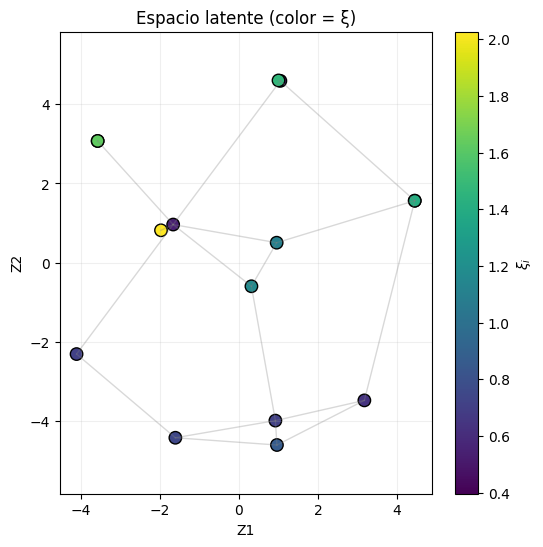

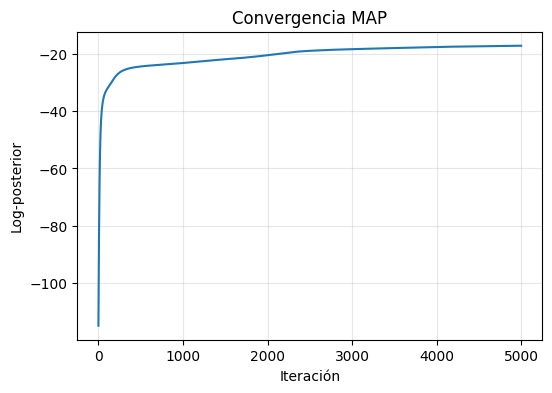

In [92]:

geometry = EuclideanGeometry(d=2, D=3*jnp.pi)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MLEInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=5,n_iter=5000)
summary = inference.summary()
print("\nLog-likelihood final:", summary["final_loglik"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1
            )

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

loglik = inference.history["loglik"]

plt.figure(figsize=(6,4))
plt.plot(loglik)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

#### MAP

In [13]:
class MAPInference(BaseInference): 
    def __init__(self, model, lr=1e-2):
        super().__init__(model)
        self.lr = lr
        self.model.inference_method = "MAP"

    def _save_state(self, grads=None):
        params = self.model.get_params()
        logpost = self.model.log_posterior()
        loglik = self.model.log_likelihood()
        logprior = self.model.log_prior()
        self.history["params"].append({
            k: v.copy() if hasattr(v, "copy") else v
            for k, v in params.items()
        })

        self.history["logpost"].append(float(logpost))
        self.history["loglik"].append(float(loglik))
        self.history["logprior"].append(float(logprior))

        if grads is not None:
            self.history["grads"].append({
                k: v.copy() if hasattr(v, "copy") else v
                for k, v in grads.items()
            })

    def step(self):
        grads = self.model.grad_log_posterior() 
        params = self.model.latent_params
        geom = self.model.geometry

        # alpha0
        if "alpha0" in params:
            params["alpha0"] = params["alpha0"] + self.lr * grads["alpha0"]

        # xi
        if "xi" in params:
            xi = params["xi"]
            gxi = grads["xi"]
            simplex = self.model.weights
            gxi = simplex.project_to_tangent(xi, gxi)
            xi_new = simplex.exponential_map(xi, self.lr * gxi)
            xi_new = simplex.project_to_domain(xi_new)
            params["xi"] = xi_new
            
        # Z
        if "Z" in params:
            Z = params["Z"]
            gZ = grads["Z"]
            Z_new = jax.vmap(geom.exponential_map)(Z, self.lr * gZ)
            Z_new = jax.vmap(geom.project_to_domain)(Z_new)
            params["Z"] = Z_new
        self._save_state(grads)

    def fit(self, n_iter=5000, tol=1e-6, patience=50, verbose=True, use_tqdm=True):
        best = -jnp.inf
        counter = 0
        iterator = tqdm(range(n_iter), desc="MAP") if use_tqdm else range(n_iter)
        for i in iterator:
            self.step()
            current = self.history["logpost"][-1]
            if use_tqdm:
                iterator.set_postfix({
                    "logpost": f"{current:.4f}",
                    "loglik": f"{self.history['loglik'][-1]:.4f}",
                    "logprior": f"{self.history['logprior'][-1]:.4f}",
                    "patience": counter
                })
            if current > best + tol:
                best = current
                counter = 0
            else:
                counter += 1
            if counter >= patience:
                if verbose:
                    msg = f"[STOP] Early stopping at iter {i} (no improvement in {patience} steps)"
                    if use_tqdm:
                        iterator.write(msg)
                    else:
                        print(msg)
                break
        self.result = self.model.get_params()
        return self.result
    
    def fit_multi_start(self, n_starts=25, n_iter=5000, tol=1e-4, patience=50, seeds=None, verbose=True, use_tqdm=True,):
        best_logpost = -jnp.inf
        best_result = None
        all_runs = []
        if seeds is None:
            seeds = list(range(n_starts))
        outer_iter = tqdm(range(n_starts), desc="Multi-start") if use_tqdm else range(n_starts)
        for k in outer_iter:
            seed = seeds[k]
            self.model.initialize_from_prior(n=self.model.Y.shape[0], seed=seed)
            self.history = {"params": [], "logpost": [], "loglik": [], "logprior": [], "grads": []}
            self.fit(n_iter=n_iter, tol=tol, patience=patience, verbose=True, use_tqdm=True)
            final_logpost = self.history["logpost"][-1]
            result = self.model.get_params()
            all_runs.append({"seed": seed, "logpost": final_logpost, "params": result})
            if final_logpost > best_logpost:
                best_logpost = final_logpost
                best_result = result
            if use_tqdm:
                outer_iter.set_postfix({"best_logpost": f"{best_logpost:.4f}"})
        self.result = best_result
        self.all_runs = all_runs
        if verbose:
            print(f"\nBest log-posterior: {best_logpost:.4f}")
        return best_result

    def summary(self):
        return {
            "final_params": self.result,
            "final_logpost": self.history["logpost"][-1] if self.history["logpost"] else None,
            "final_loglik": self.history["loglik"][-1] if self.history["loglik"] else None,
            "final_logprior": self.history["logprior"][-1] if self.history["logprior"] else None
        }

Multi-start:  20%|██        | 1/5 [00:31<02:07, 31.91s/it, best_logpost=-22.6116]

[STOP] Early stopping at iter 3975 (no improvement in 50 steps)



Multi-start:  40%|████      | 2/5 [02:07<03:27, 69.13s/it, best_logpost=-22.6116]

[STOP] Early stopping at iter 8464 (no improvement in 50 steps)


Multi-start:  60%|██████    | 3/5 [03:14<02:16, 68.16s/it, best_logpost=-22.0746]

[STOP] Early stopping at iter 8703 (no improvement in 50 steps)


Multi-start: 100%|██████████| 5/5 [05:42<00:00, 68.41s/it, best_logpost=-19.0305]


[STOP] Early stopping at iter 9106 (no improvement in 50 steps)

Best log-posterior: -19.0305

Log-posterior final: -19.030500411987305
alpha0: 2.7742374
xi: [1.234741   0.42796093 1.0224149  1.0866724  0.9024225  0.93616074
 1.1394777  1.0664529  0.55199707 1.03575    1.4868506  0.87060523
 0.583798   1.3034608  1.3512342 ]
Z: [[-4.709068    0.1768981 ]
 [-2.8652809   0.39670417]
 [-0.7638366  -4.650071  ]
 [ 1.2689054  -4.538336  ]
 [ 1.0239624  -4.027101  ]
 [-3.1347933  -3.518477  ]
 [-0.3813233  -0.7829273 ]
 [ 0.2302916   0.17864044]
 [ 2.239422    4.1462755 ]
 [-3.064957    3.579476  ]
 [-2.6205328   3.9165568 ]
 [ 3.0398405  -3.6008308 ]
 [ 4.2006836   0.30954906]
 [ 1.8921882   4.315812  ]
 [ 4.6996493   0.34627506]]


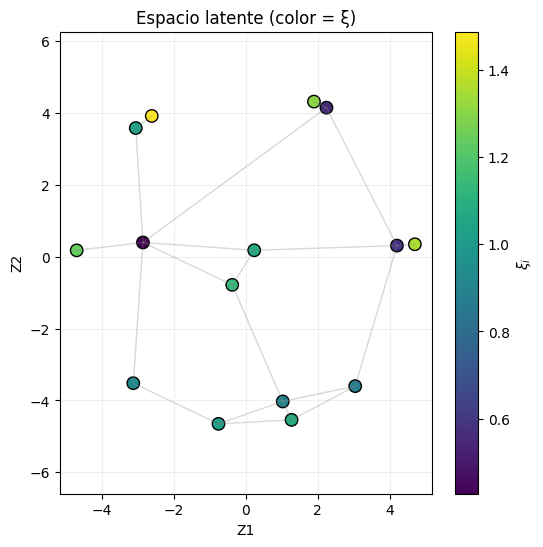

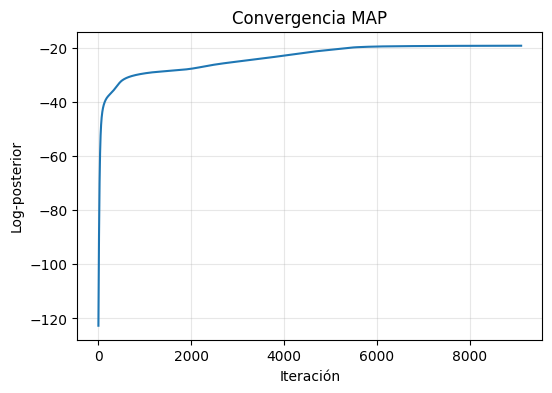

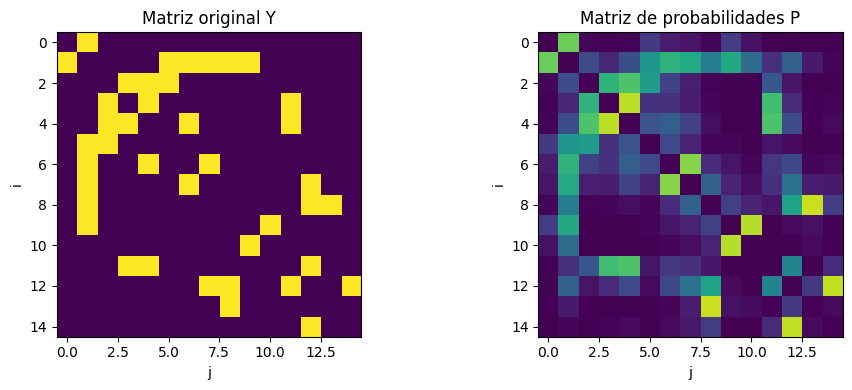

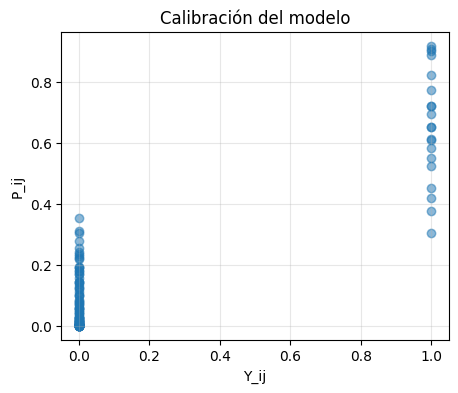

In [18]:

geometry = EuclideanGeometry(d=2, D=3*jnp.pi)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference( model, lr=5e-3)
result = inference.fit_multi_start(n_starts=5,n_iter=10000, tol=1e-3)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1)

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

from scipy.special import expit

# =========================
# Matriz de probabilidades
# =========================

n = Z_np.shape[0]
P = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            # distancia euclidiana (consistente con tu geometry actual)
            dij = np.linalg.norm(Z_np[i] - Z_np[j])
            
            sij = alpha0 - 0.5 * (xi_np[i] + xi_np[j]) * dij
            P[i, j] = expit(sij)

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Multi-start:  40%|████      | 2/5 [00:49<01:13, 24.37s/it, best_logpost=-22.7838]

[STOP] Early stopping at iter 3666 (no improvement in 50 steps)



Multi-start:  60%|██████    | 3/5 [01:14<00:49, 24.64s/it, best_logpost=-22.7838]

[STOP] Early stopping at iter 3885 (no improvement in 50 steps)



Multi-start:  80%|████████  | 4/5 [01:40<00:25, 25.18s/it, best_logpost=-22.7838]

[STOP] Early stopping at iter 3929 (no improvement in 50 steps)



Multi-start: 100%|██████████| 5/5 [02:02<00:00, 24.57s/it, best_logpost=-22.7838]


[STOP] Early stopping at iter 3375 (no improvement in 50 steps)

Best log-posterior: -22.7838

Log-posterior final: -24.870437622070312
alpha0: 2.7894437
xi: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Z: [[-3.2215576  -3.4392116 ]
 [-1.489578   -0.5789784 ]
 [ 0.40322694  4.695106  ]
 [ 2.4017534   4.0544043 ]
 [ 1.9891288   3.5593703 ]
 [-1.9285427   3.8397322 ]
 [-0.1061485   0.68951464]
 [ 0.28449365 -0.24915479]
 [ 1.1724434  -3.2822216 ]
 [-4.504418    0.24597117]
 [-4.6802845   0.54912996]
 [ 3.6704962   2.6347754 ]
 [ 3.162282   -0.84959567]
 [ 1.0916839  -4.584194  ]
 [ 4.531634   -1.2926351 ]]


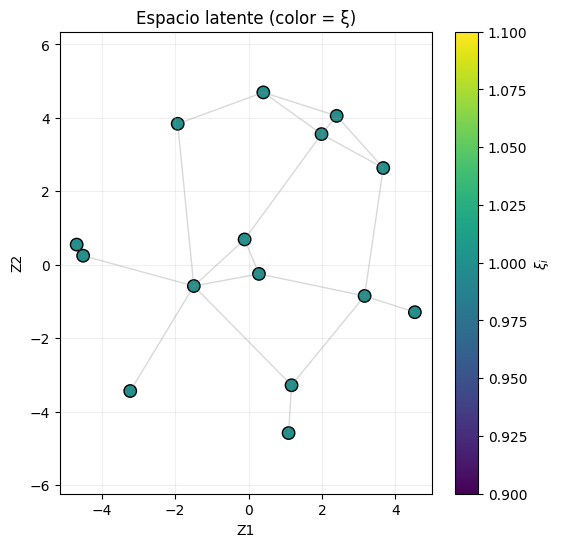

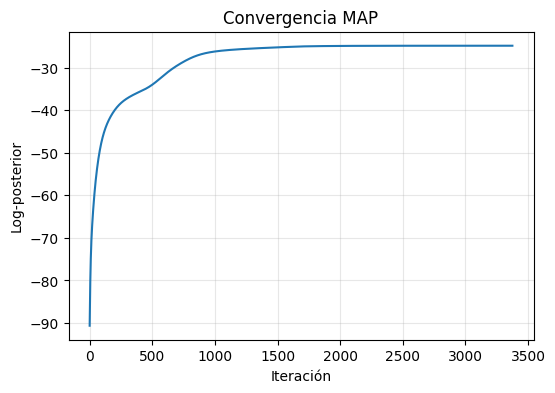

In [89]:

geometry = EuclideanGeometry(d=2, D=3*jnp.pi)

model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi":jnp.ones(15)})
inference = MAPInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=5,n_iter=5000)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1
            )

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

#### MCMC

In [26]:
class MCMCInference(BaseInference):
    def __init__(self, model, eps_alpha0=1e-2, eps_xi=1e-2, eps_Z=1e-2, target_accept_alpha0=0.57, target_accept_xi=0.57, target_accept_Z=0.5):
        super().__init__(model)
        self.eps_alpha0 = eps_alpha0
        self.eps_xi = eps_xi
        self.eps_Z = eps_Z
        self.target_alpha0 = target_accept_alpha0
        self.target_xi = target_accept_xi
        self.target_Z = target_accept_Z

        self.geometry = self.model.geometry

        self.model.inference_method = "MCMC"
    
    # Log q
    def _log_q(self, x_new, x, grad_x, eps):
        mean = x + 0.5 * eps**2 * grad_x
        diff = x_new - mean
        return -0.5 * jnp.sum(diff**2) / (eps**2)

    def _log_q_manifold(self, z_new, z, grad_z, eps):
        v = jax.vmap(self.geometry.logaritmic_map)(z, z_new)
        mean = 0.5 * eps**2 * grad_z
        diff = v - mean
        return -0.5 * jnp.sum(diff**2) / (eps**2)

    # Adapt step size (Robbins–Monro)
    def _adapt(self, eps, accept, target, t):
        gamma = (t + 1) ** (-0.6)
        log_eps = jnp.log(eps) + gamma * (accept - target)
        return jnp.exp(log_eps)

    # Steps
    def step_alpha0(self, key):
        eps = self.eps_alpha0
        p = self.model.get_params()
        alpha0 = p["alpha0"]
        grad = self.model.grad_log_posterior()["alpha0"]
        key1, key2 = jax.random.split(key)
        noise = jax.random.normal(key1)
        prop = alpha0 + 0.5 * eps**2 * grad + eps * noise
        logp_current = self.model.log_posterior()
        self.model.latent_params["alpha0"] = prop
        logp_prop = self.model.log_posterior()
        grad_prop = self.model.grad_log_posterior()["alpha0"]
        log_q_f = self._log_q(prop, alpha0, grad, eps)
        log_q_b = self._log_q(alpha0, prop, grad_prop, eps)
        log_accept = logp_prop + log_q_b - logp_current - log_q_f
        if jnp.log(jax.random.uniform(key2)) < log_accept:
            return 1.0
        else:
            self.model.latent_params["alpha0"] = alpha0
            return 0.0

    def step_xi(self, key):
        eps = self.eps_xi
        p = self.model.get_params()
        xi = p["xi"]
        grad = self.model.grad_log_posterior()["xi"]
        simplex = self.model.weights
        grad = simplex.project_to_tangent(xi, grad)
        key1, key2 = jax.random.split(key)
        noise = jax.random.normal(key1, shape=xi.shape)
        noise = simplex.project_to_tangent(xi, noise)
        v = 0.5 * eps**2 * grad + eps * noise
        xi_prop = simplex.exponential_map(xi, v)
        xi_prop = simplex.project_to_domain(xi_prop)
        logp_current = self.model.log_posterior()
        self.model.latent_params["xi"] = xi_prop
        logp_prop = self.model.log_posterior()
        grad_prop = self.model.grad_log_posterior()["xi"]
        grad_prop = simplex.project_to_tangent(xi_prop, grad_prop)
        log_q_f = self._log_q(xi_prop, xi, grad, eps)
        log_q_b = self._log_q(xi, xi_prop, grad_prop, eps)
        log_accept = logp_prop + log_q_b - logp_current - log_q_f
        if jnp.log(jax.random.uniform(key2)) < log_accept:
            return 1.0
        else:
            self.model.latent_params["xi"] = xi
            return 0.0
    def step_Z(self, key):
        eps = self.eps_Z
        geom = self.model.geometry
        Z = self.model.get_params()["Z"]
        n = Z.shape[0]
        keys = jax.random.split(key, n)
        accepted = 0.0
        for i in range(n):
            zi = Z[i]
            grad = self.model.grad_log_posterior()["Z"][i]
            grad = geom.project_to_tangent(zi, grad)
            key1, key2 = jax.random.split(keys[i])
            noise = jax.random.normal(key1, shape=zi.shape)
            noise = geom.project_to_tangent(zi, noise)
            v = 0.5 * eps**2 * grad + eps * noise
            zi_prop = geom.exponential_map(zi, v)
            zi_prop = geom.project_to_domain(zi_prop)
            Z_prop = Z.at[i].set(zi_prop)
            logp_current = self.model.log_posterior()
            self.model.latent_params["Z"] = Z_prop
            logp_prop = self.model.log_posterior()
            grad_prop = self.model.grad_log_posterior()["Z"][i]
            grad_prop = geom.project_to_tangent(zi_prop, grad_prop)
            log_q_f = self._log_q_manifold(zi_prop, zi, grad, eps)
            log_q_b = self._log_q_manifold(zi, zi_prop, grad_prop, eps)
            log_accept = logp_prop + log_q_b - logp_current - log_q_f
            if jnp.log(jax.random.uniform(key2)) < log_accept:
                Z = Z_prop
                accepted += 1.0
            else:
                self.model.latent_params["Z"] = Z
        self.model.latent_params["Z"] = Z
        return accepted / n

    def fit(self, n_samples=1000, burnin=1000, thin=1, seed=0, verbose=True, Z_ref=None, init_params={}):

        if init_params:
            self.model.latent_params = {
                k: v for k, v in init_params.items()
                if k not in self.model.fixed_params
            }
        else:
            self.model.initialize_from_prior(
                n=self.model.Y.shape[0],
                seed=seed
            )

        key = jax.random.PRNGKey(seed)
        total_iters = burnin + n_samples * thin
        samples = []
        self.history = {"logpost": [], "loglik": [], "logprior": [],
                        "eps": {"alpha0": [], "xi": [], "Z": []}, 
                        "acceptance": {"alpha0": [], "xi": [], "Z": []}}
        self.Z_ref = Z_ref
        self._Z_ref_initialized = Z_ref is not None
        

        iterator = tqdm(range(total_iters), desc="MCMC") if verbose else range(total_iters)
        for t in iterator:
            key, subkey = jax.random.split(key)
            k1, k2, k3 = jax.random.split(subkey, 3)
            acc_a = self.step_alpha0(k1) if "alpha0" in self.model.latent_params else 1.0
            acc_x = self.step_xi(k2) if "xi" in self.model.latent_params else 1.0
            acc_z = self.step_Z(k3) if "Z" in self.model.latent_params else 1.0

            if (not self._Z_ref_initialized) and (t == burnin):
                self.Z_ref = self.model.get_params()["Z"]
                self._Z_ref_initialized = True

            if self._Z_ref_initialized:
                Z = self.model.latent_params["Z"]
                Z = self.geometry.identifiability_transform(Z, self.Z_ref)
                self.model.latent_params["Z"] = Z


            self.history["acceptance"]["alpha0"].append(float(acc_a))
            self.history["acceptance"]["xi"].append(float(acc_x))
            self.history["acceptance"]["Z"].append(float(acc_z))

            if t < burnin:
                self.eps_alpha0 = self._adapt(self.eps_alpha0, acc_a, self.target_alpha0, t)
                self.eps_xi     = self._adapt(self.eps_xi, acc_x, self.target_xi, t)
                self.eps_Z      = self._adapt(self.eps_Z, acc_z, self.target_Z, t)
            loglik = self.model.log_likelihood()
            logprior = self.model.log_prior()
            logpost = loglik + logprior  #self.model.log_posterior()
            self.history["loglik"].append(float(loglik))
            self.history["logprior"].append(float(logprior))
            self.history["logpost"].append(float(logpost))
            self.history["eps"]["alpha0"].append(float(self.eps_alpha0))
            self.history["eps"]["xi"].append(float(self.eps_xi))
            self.history["eps"]["Z"].append(float(self.eps_Z))


            if t >= burnin and ((t - burnin) % thin == 0):
                samples.append({ k: v.copy() if hasattr(v, "copy") else v for k, v in self.model.get_params().items()})
            if verbose:
                acc_total = 0.0
                acc_total += np.mean(np.array(self.history["acceptance"]["alpha0"]))
                acc_total += np.mean(np.array(self.history["acceptance"]["xi"]))
                acc_total += np.mean(np.array(self.history["acceptance"]["Z"]))
                acc_total /= 3
                iterator.set_postfix({"logpost": f"{logpost:.3f}", "loglik": f"{loglik:.3f}", "logprior": f"{logprior:.3f}",
                                       "acceptance": f"{acc_total:.3f}"})

        self.samples = samples
        return samples

In [25]:

geometry = EuclideanGeometry(d=2, D=3*jnp.pi)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MCMCInference(model)
result = inference.fit(n_samples=1000, burnin=1000, thin=1)

MCMC: 100%|██████████| 2000/2000 [04:24<00:00,  7.57it/s, logpost=-29.916, acceptance=0.568]


Array([1.000e-03, 2.000e-03, 3.000e-03, ..., 1.234e+00, 1.235e+00,
       1.235e+00], dtype=float32)

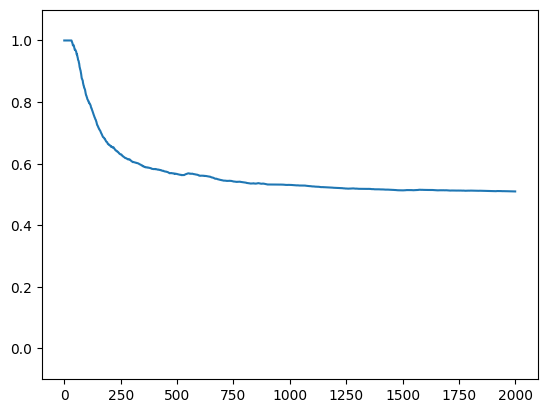

In [66]:
plt.plot(jnp.cumulative_sum(jnp.array(inference.history['acceptance']['Z'])) / jnp.array(range(1,2001)))
plt.ylim(-0.1,1.1)
plt.show()

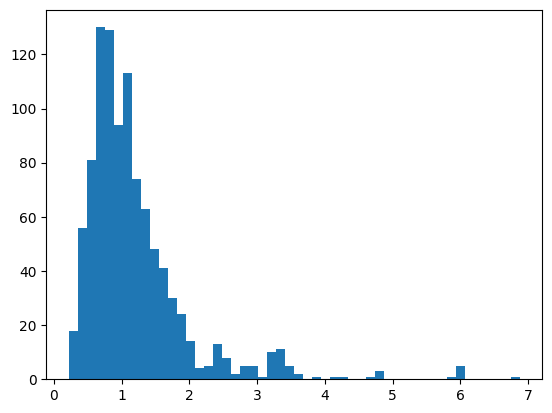

In [39]:
plt.hist(np.array([result[l]['xi'] for l in range(1000)])[:,14],bins=50)
plt.show()

#### Variational inference

### Analysis

## Generative model

### Experiment A: Conditional in the parameters
Fix a sample of the prior and simulate many networks

### Experiment B: Marginal
Resample from the prior each time and generate a network for each sample from the prior

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

### Model $\mathbb{R}^2$

### Model $\mathbb{R}^3$

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

### Model $\mathbb{S}^2$

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

### Model $\mathbb{H}^2$